# Carregamento de Bibliotecas e do Dataframe

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
# Configuração para que todo dataFrame seja exibido no notebook no padrão brasileiro
# Mostrando os números com duas casas decimais e separador de milhar e sem notação científica

pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

In [4]:
#Carrega o csv em uma variável to tipo pandas dataframe
df_viagem = pd.read_csv(
    '2026_Viagem.csv', 
    sep=';', 
    decimal=',', 
    encoding='latin-1', 
    parse_dates=['Período - Data de início', 'Período - Data de fim'],
    dayfirst=True  # <-- data no formato brasileiro (dd/mm/yyyy)
)


Primeiramente vamos dar uma olhada geral nas primeiras linhas do dataframe para ter uma compreensão inicial de como estão os dados. 

In [5]:
df_viagem.head(10)

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,...,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos
0,21116870,000073/26,Realizada,SIM,Atraso na solicitação,26000,Ministério da Educação,26436,"Instituto Federal de Educação, Ciência e Tecno...",***.240.140-**,...,FG-0001,FG-0001,2026-02-25,2026-02-25,Venâncio Aires/RS,Motivo da viagem (objeto/assunto a ser tratado...,"107,83","0,00","0,00","0,00"
1,21126303,000001/26,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,...,-1,Sem informação,2026-01-25,2026-07-24,Pelotas/RS,Pesquisa com colaboração de professores da Uni...,"0,00","0,00","0,00","0,00"
2,21342207,000001/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.506.203-**,...,Sargento,Sargentos,2026-01-09,2026-01-10,Washington/Estados Unidos da América,A fim de exercer o cargo de Auxiliar da Seção ...,"0,00","5.927,18","0,00","0,00"
3,21343024,000001/26,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26247,Universidade Federal de Santa Maria,***.464.017-**,...,-1,Sem informação,2026-02-28,2026-03-08,Montevidéu/Uruguai,"O docente RODRIGO MARINHO DE SOUZA, SIAPE 1296...","0,00","0,00","0,00","0,00"
4,21346664,000002/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.526.753-**,...,-1,Sem informação,2026-01-09,2026-01-10,Washington/Estados Unidos da América,Acompanhar militar designado para missão no ex...,"0,00","5.927,18","0,00","0,00"
5,21347000,000003/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.826.321-**,...,-1,Sem informação,2026-01-09,2026-01-10,Washington/Estados Unidos da América,Acompanhar militar desisgnado para missão no e...,"0,00","5.927,18","0,00","0,00"
6,21347334,000004/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.927.111-**,...,-1,Sem informação,2026-01-09,2026-01-10,Washington/Estados Unidos da América,Acompanhar militar desisgnado para missão no e...,"0,00","803,28","0,00","0,00"
7,21354924,000005/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.840.747-**,...,OfSuperior,OfSuperior,2026-01-23,2026-01-25,San Salvador/El Salvador,Movimentação de militar por início de missão n...,"0,00","2.163,26","0,00","2.786,10"
8,21355148,000006/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.482.377-**,...,-1,Sem informação,2026-01-23,2026-01-25,San Salvador/El Salvador,Viagem de dependente para acompanhar militar e...,"0,00","2.163,26","0,00","0,00"
9,21355252,000007/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.846.997-**,...,-1,Sem informação,2026-01-23,2026-01-25,San Salvador/El Salvador,Viagem da dependente para acompanhar o militar...,"0,00","2.163,26","0,00","0,00"


In [4]:
df_viagem.info()

<class 'pandas.DataFrame'>
RangeIndex: 406083 entries, 0 to 406082
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   Identificador do processo de viagem  406083 non-null  int64         
 1   Número da Proposta (PCDP)            406083 non-null  str           
 2   Situação                             406083 non-null  str           
 3   Viagem Urgente                       406083 non-null  str           
 4   Justificativa Urgência Viagem        405907 non-null  str           
 5   Código do órgão superior             406083 non-null  int64         
 6   Nome do órgão superior               406083 non-null  str           
 7   Código órgão solicitante             406083 non-null  int64         
 8   Nome órgão solicitante               406083 non-null  str           
 9   CPF viajante                         369197 non-null  str           
 10  Nome   

# Apresentação da Base de Dados
<p> Esta base foi obtida pelo portal da transparência e trata-se das viagens realizadas por servidores públicos a serviço dos diversos órgãos no ano de 2026, atualizada até dia 16/08/2026. O link para a base encontra-se no README do projeto. </p>

Como pode-se observar pelo df.info() executado anteriormente tratam-se de 22 colunas. A maioria das colunas é auto-explicativa e a bse contém pouco mais de 406 mil linhas.

Os valores monetários relacionados as quatro últimas colunas são em BRL.

As datas de inicio e fim das viagens estão no formato americano de ano-mes-dia ou também conhecido como yyyy-mm-dd

# Perguntas que gostaríamos de responder

-1 Quais órgãos públicos realizam mais viagens e concentram os maiores gastos? Como o gasto se distribui entre os órgaos e qual o custo médio por viagem ?

-2 Quais características estão associadas às viagens de maior custo? Existem viagens ou viajantes com gastos significativamente acima do padrão ?

-3 Qual é a composição dos gastos nas suas categorias : diárias, passagens, outros gastos, etc.

-4 Qual é a proporção de viagens realizadas vs não realizadas ? Qual o impacto financeiro das viagens não realizadas ? 

-5 Viagens marcadas como urgente apresentam custo médio maior do que viagens não urgentes? Existe correlação entre urgência e custo da viagem ? 

## Valores "Sem informação" e "Sem informaçã":
- Verificar a relevância das colunas para as perguntas a serem respondidas.  
- Não há necessidade de tratamento, se as colunas e esses valores não forem relevantes para as perguntas da análise.

#### Contagem por coluna de registros com valor "Sem informação"

| Coluna | Registros |
|:---|---:|
| Descrição Função | 191.806 |
| Justificativa Urgência Viagem | 112.914 |
| Destinos | 1.206 |

#### Contagem por coluna de registros com valor "Sem informaçã"

| Coluna | Registros |
|:---|---:|
| Número da Proposta (PCDP) | 677 |

In [ ]:
# Valores nulos:
diag_nulos = pd.DataFrame({
    'faltantes': df_viagem.isna().sum(),
    'pct': (df_viagem.isna().mean() * 100).round(2),
    'distintos': df_viagem.nunique(),
})
print("Diagnóstico de dados nulos:")
display(diag_nulos[diag_nulos['faltantes'] > 0].sort_values('faltantes', ascending=False))

print("linhas com algum faltante:", df_viagem.isna().any(axis=1).sum())
print("linhas completas         :", df_viagem.notna().all(axis=1).sum())

# Contagem do valor "Sem informação":
contagem1 = (df_viagem == "Sem informação").sum()
contagem1 = contagem1[contagem1 > 0].sort_values(ascending=False)

print('\nContagem por coluna de registros com valor "Sem informação":')
print(contagem1)

# Contagem do valor "Sem informaçã":
contagem2 = (df_viagem == "Sem informaçã").sum()
contagem2 = contagem2[contagem2 > 0].sort_values(ascending=False)

print('\nContagem por coluna de registros com valor "Sem informaçã":')
print(contagem2)



## Registros sem movimentação financeira

A inspeção inicial de df_viagem revelou registros onde todos os valores monetários constam como zerados. O filtro identificou 24.293 linhas nessa condição.

Para verificar se representam ausência real de desembolso, os identificadores desses processos foram confrontados com a tabela 2026_Pagamento. As colunas de identificador têm o mesmo tipo (int64), permitindo a comparação direta. O cruzamento retornou conjunto vazio: nenhum desses processos possui pagamento registrado.

Conclui-se que a tabela de pagamentos não registra viagens sem desembolso, confirmando que os valores zerados refletem ausência de despesa — e não falha de preenchimento. Assim, esses registros foram excluídos do escopo da nossa análise.


In [ ]:
# Criando um filtro para listar somente as colunas de valores monetários:
colunas_valores_monetarios = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos"]

#Filtrando as linhas onde todos os valores monetários estão zerados:
df_zerados = df_viagem[df_viagem[colunas_valores_monetarios].eq(0).all(axis=1)]
print(f'Quantidade de linhas e colunas onde todos os valores de gastos são zero: {df_zerados.shape[0]} linhas e {df_zerados.shape[1]} colunas \n')

### _Os identificadores do processo de viagem de df_zerados constam nos dados da tabela 2026_Pagamento?_

In [ ]:
# Abrindo o arquivo 2026_Pagamento com ajuste dos valores com casa decimal:
df_pagamento = pd.read_csv('2026_Pagamento.csv', sep=';', decimal=',', encoding='latin-1')
display(df_pagamento.head(3))

# Checando se os dados dos id's (identificadores de viagem) das duas tabelas são do mesmo tipo e podem ser comparados: 
print('\nTipo de dados das colunas a serem comparadas:')
print(df_viagem["Identificador do processo de viagem"].dtype)
print(df_pagamento["Identificador do processo de viagem"].dtype)

## Checando se na tabela de pagamentos constam os Id's refrente aos registros com todos os valores monetarios zerados:
 
# Criando série dos id's de df_zerados
id_valores_monetarios = df_zerados['Identificador do processo de viagem']

df_pag_zerados = df_pagamento[
    df_pagamento["Identificador do processo de viagem"].isin(id_valores_monetarios)
]

print("\nDataframe de checagem:")
print(f'Processos zerados com pagamento registrado: {len(df_pag_zerados)}')
df_pag_zerados

## Exclusão das linhas onde todos os valores monetários constam como zerados

In [ ]:
valores_monetarios = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos"]

df_viagem_limpo = df_viagem[~df_viagem[valores_monetarios].eq(0).all(axis=1)].copy()

print(f'Antes: {len(df_viagem)} | Depois: {len(df_viagem_limpo)} | Removidas: {len(df_viagem) - len(df_viagem_limpo)}')

In [ ]:
df_viagem = df_viagem_limpo
print("Shape:",df_viagem.shape)

## Inclusão das colunas Gasto Total e Gasto líquido

In [12]:
# Incluindo as colunas Gasto Total e Gasto líquido
colunas_gastos = ["Valor diárias", "Valor passagens", "Valor outros gastos"]
df_viagem['Gasto total'] = df_viagem[colunas_gastos].sum(axis=1)
df_viagem['Gasto líquido'] = (
    df_viagem[colunas_gastos].sum(axis=1)
    - df_viagem['Valor devolução']
)
print("shape", df_viagem.shape)
df_viagem.head(3)

shape (406083, 24)


,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,...,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Gasto total,Gasto líquido
0,21116870,000073/26,Realizada,SIM,Atraso na solicitação,26000,Ministério da Educação,26436,"Instituto Federal de Educação, Ciência e Tecno...",***.240.140-**,...,2026-02-25,2026-02-25,Venâncio Aires/RS,Motivo da viagem (objeto/assunto a ser tratado...,"107,83","0,00","0,00","0,00","107,83","107,83"
1,21126303,000001/26,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,...,2026-01-25,2026-07-24,Pelotas/RS,Pesquisa com colaboração de professores da Uni...,"0,00","0,00","0,00","0,00","0,00","0,00"
2,21342207,000001/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.506.203-**,...,2026-01-09,2026-01-10,Washington/Estados Unidos da América,A fim de exercer o cargo de Auxiliar da Seção ...,"0,00","5.927,18","0,00","0,00","5.927,18","5.927,18"


## Resumo Estatístico para as colunas de valores dos gastos:

In [ ]:
# Resumo estatísitco das colunas de gastos:
colunas_gastos = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos", "Gasto total", "Gasto líquido"]
resumo_estatisco = round(df_viagem[colunas_gastos].describe(), 2)
resumo_estatisco

> **Registros com gasto líquido negativo.** Foram identificados 5 registros (0,001% da base, saldo de R$ -2.235,00) em que o valor devolvido supera o gasto total. As diferenças concentram-se em múltiplos de R$ 0,50, compatíveis com valores de diária, o que sugere retificação do valor da viagem posterior ao registro da devolução — antecipação de retorno ou supressão de trecho — ou devolução referente a exercício anterior. Todos os casos são de viagens realizadas, o que afasta a hipótese de falha sistemática no campo. Dado o impacto de 0,0002% sobre o gasto líquido total, os registros foram mantidos sem ajuste.

In [ ]:
neg = df_viagem['Gasto líquido'] < 0
if neg.any():
    display(df_viagem.loc[neg, ['Identificador do processo de viagem', 'Situação',
                                'Gasto total', 'Valor devolução', 'Gasto líquido']])

print(f'{neg.sum()} registros ({100*neg.mean():.3f}% da base)')
print(f'Soma dos saldos negativos: R$ {df_viagem.loc[neg, "Gasto líquido"].sum():,.2f}')
print(f'Impacto no gasto líquido total: {100*abs(df_viagem.loc[neg, "Gasto líquido"].sum()) / df_viagem["Gasto líquido"].sum():.4f}%')
display(df_viagem.loc[neg, 'Situação'].value_counts())

## Análise de viagens que constam na situação "Não realizada"

### _Qual é a proporção de viagens realizadas e não realizadas, e qual o impacto financeiro das viagens não realizadas?_

Para tentar responder a essas perguntas iniciamos com análises por agregação da tabela de viagens segundo o campo Situação, que classifica cada processo como realizado ou não realizado e resultaram em dois quadros que resumem cada situação considerando o gasto total (Resumo Comparativo entre Viagens Realizadas e Não Realizadas) e também os valores devolvidos (Valor Devolvido por Viagens Realizadas e Não Realizadas)  

As proporções (`% das viagens`, `% do gasto`) dividem cada linha pelo total da coluna e respondem à questão do peso numérico e financeiro de cada grupo.    

Além da média, incluem-se mediana e percentil 95, dada a assimetria da distribuição de gastos, em que valores extremos comprometem a representatividade da média. A razão média/mediana sintetiza essa assimetria.

No quadro de devoluções, as estatísticas de posição são calculadas apenas sobre registros com devolução positiva (`s[s > 0]`) — do contrário, os milhares de zeros diluiriam as medidas.

In [ ]:
# Resumo de viagens realizadas e não realiazdas
print("\nRESUMO COMPARATIVO ENTRE VIAGENS REALIZADAS E NÃO REALIZADAS:")

resumo_por_situacao = df_viagem_limpo.groupby("Situação").agg(
    **{
        'Qtde de viagens':        ('Identificador do processo de viagem', 'count'),
        'Gasto total (R$)':       ('Gasto total', 'sum'),
        'Gasto médio (R$)':       ('Gasto total', 'mean'),
        'Gasto mediano (R$)':     ('Gasto total', 'median'),
        'Gasto P95 (R$)':         ('Gasto total', lambda s: s.quantile(0.95)),
        'Maior gasto (R$)':       ('Gasto total', 'max'),
    }
).assign(**{
    '% das viagens':  lambda d: d['Qtde de viagens'] / d['Qtde de viagens'].sum() * 100,
    '% do gasto':     lambda d: d['Gasto total (R$)'] / d['Gasto total (R$)'].sum() * 100,
    'Assimetria (méd/med)': lambda d: d['Gasto médio (R$)'] / d['Gasto mediano (R$)'],
}).sort_values('Gasto total (R$)', ascending=False)

display(resumo_por_situacao)

# Resumo dos valores devolvidos por situação (Realizada e Não realizada)

print("\nVALOR DEVOLVIDO POR VIAGENS REALIZADAS E NÃO REALIZADAS:")

vr_devolvido_por_situacao = df_viagem_limpo.groupby("Situação").agg(
    **{
        'Qtde de viagens':          ('Valor devolução', 'size'),
        'Viagens com devolução':    ('Valor devolução', lambda s: (s > 0).sum()),
        'Total devolvido (R$)':     ('Valor devolução', 'sum'),
        'Devolução média (R$)':     ('Valor devolução', lambda s: s[s > 0].mean()),
        'Devolução mediana (R$)':   ('Valor devolução', lambda s: s[s > 0].median()),
        'Devolução P95 (R$)':       ('Valor devolução', lambda s: s[s > 0].quantile(0.95)),
        'Maior devolução (R$)':     ('Valor devolução', 'max'),
        '_gasto':                   ('Gasto total', 'sum'), #  coluna criada para viabilizar o indicador `% do gasto recuperado`. Foi descartada ao final.
    }
).assign(**{
    '% viagens c/ devolução':  lambda d: d['Viagens com devolução'] / d['Qtde de viagens'] * 100,
    '% do total devolvido':    lambda d: d['Total devolvido (R$)'] / d['Total devolvido (R$)'].sum() * 100,
    '% do gasto recuperado':   lambda d: d['Total devolvido (R$)'] / d['_gasto'] * 100,
}).sort_values('Total devolvido (R$)', ascending=False).drop(columns='_gasto')

display(vr_devolvido_por_situacao)


### Proporção de viagens realizadas e não realizadas

Em 381.790 processos de viagem, o cancelamento é exceção: 98,72% dos afastamentos autorizados se concretizaram. Apenas 4.878 viagens não foram realizadas. Esse volume aparentemente marginal, no entanto, não se traduz proporcionalmente quando se observa o dinheiro envolvido.

### Viagens não realizadas: baixa incidência, alto custo unitário e recuperação limitada

As viagens não realizadas somam 1,28% dos processos (4.878 de 381.790), mas 1,85% do gasto, com R$ 21,79 milhões comprometidos.

**São sistematicamente mais caras.** O gasto mediano das canceladas (R$ 3.391,74) supera em 116% o das realizadas (R$ 1.566,92). Por ser a diferença entre medianas maior que entre médias, o padrão não decorre de casos extremos. Os percentis 95 são praticamente iguais (R$ 9.476 e R$ 9.236): ambos os grupos têm o mesmo teto, mas faltam viagens de baixo valor entre as canceladas. A hipótese mais consistente é de composição — cancelamentos com custo concentram-se em deslocamentos complexos, com passagem já emitida.

**A devolução reage ao cancelamento, mas recupera pouco.** Entre as não realizadas, 33,58% tiveram devolução, contra 2,50% das realizadas — frequência 13 vezes maior. A mediana devolvida também é superior (R$ 1.219,96 contra R$ 97,34), indicando que a restituição em viagens realizadas é majoritariamente residual. Ainda assim, recuperou-se apenas 13,68% do valor comprometido, e dois terços dos cancelamentos (3.240 processos) não registraram devolução.

**Resultado líquido:** R$ 18,81 milhões em viagens que não se realizaram — 1,6% do gasto total da base, conforme código descrito abaixo.

In [ ]:
# Resultado líquido das viagens não realizadas
nr = df_viagem[df_viagem['Situação'] == 'Não realizada']

comprometido = nr['Gasto total'].sum()
devolvido    = nr['Valor devolução'].sum()
liquido      = nr['Gasto líquido'].sum()
base_total   = df_viagem['Gasto total'].sum()

print('VIAGENS NÃO REALIZADAS — RESULTADO LÍQUIDO')
resultado_liq = pd.DataFrame({
    'Indicador': ['Processos não realizados',
                  'Gasto comprometido (R$)',
                  'Valor devolvido (R$)',
                  'Gasto líquido (R$)',
                  '% do gasto total da base',
                  '% do comprometido recuperado'],
    'Valor': [f'{len(nr):,}',
              f'{comprometido:,.2f}',
              f'{devolvido:,.2f}',
              f'{liquido:,.2f}',
              f'{100*liquido/base_total:.2f}%',
              f'{100*devolvido/comprometido:.2f}%']
})
display(resultado_liq)

In [ ]:
# Filtrando não realizadas:
df_nao_realizadas = df_viagem_limpo[df_viagem_limpo["Situação"]=="Não realizada"]
print('Qtde de linhas e colunas:',df_nao_realizadas.shape)

# Comparando não realizadas com a tabela 2026_Pagamento:
id_nao_realizadas = df_nao_realizadas['Identificador do processo de viagem']

df_pagto_nao_realizadas = df_pagamento[
    df_pagamento["Identificador do processo de viagem"].isin(id_nao_realizadas)
]

df_pagto_nao_realizadas.shape

In [ ]:
resumo = df_pagto_nao_realizadas.groupby('Nome do órgão superior').agg(
    qtd_processos=('Identificador do processo de viagem', 'nunique'),
    qtd_pagamentos=('Identificador do processo de viagem', 'count'),
    total_pago=('Valor', 'sum'),
    media_paga=('Valor', 'mean'),
    maior_pago=('Valor', 'max')
).sort_values('total_pago', ascending=False)

In [ ]:
resumo.loc['TOTAL'] = [
    df_pagto_nao_realizadas['Identificador do processo de viagem'].nunique(),
    df_pagto_nao_realizadas['Identificador do processo de viagem'].count(),
    df_pagto_nao_realizadas['Valor'].sum(),
    df_pagto_nao_realizadas['Valor'].mean(),
    df_pagto_nao_realizadas['Valor'].max()
]

resumo.sort_values('Nome do órgão superior')

# ANÁLISE #1

## Quais órgãos públicos realizam mais viagens e concentram os maiores gastos? 

In [ ]:
# Podemos excluir esta box depois, só pra lembrar as colunas neste ponto.
df_viagem.info()

In [26]:
df_valores_de_viagens_agrupados_por_orgao = df_viagem[['Nome do órgão superior', 'Valor diárias', 'Valor passagens', 'Valor outros gastos', 'Gasto total']].groupby(["Nome do órgão superior"]).sum()

In [25]:
display(df_valores_de_viagens_agrupados_por_orgao)

,Valor diárias,Valor passagens,Valor outros gastos,Gasto total
Nome do órgão superior,,,,
Advocacia-Geral da União,"2.418.373,52","3.386.154,17","42.488,90","5.847.016,59"
Banco Central do Brasil - Orçamento Fiscal e Seguridade Social,"1.945.512,75","2.295.515,78","75.117,61","4.316.146,14"
Controladoria-Geral da União,"970.229,90","843.658,53","6.088,76","1.819.977,19"
Ministério da Agricultura e Pecuária,"13.233.532,74","10.898.931,52","205.608,24","24.338.072,50"
"Ministério da Ciência, Tecnologia e Inovação","5.452.626,42","9.765.087,25","59.558,37","15.277.272,04"
Ministério da Cultura,"4.282.844,32","8.962.468,15","24.436,51","13.269.748,98"
Ministério da Defesa,"78.222.715,31","69.696.857,51","882.311,52","148.801.884,34"
Ministério da Educação,"73.670.335,95","80.900.052,88","1.265.531,06","155.835.919,89"
Ministério da Fazenda,"24.728.064,38","23.527.884,45","685.495,83","48.941.444,66"


In [21]:
df_valores_de_viagens_agrupados_por_orgao.describe()

,Valor diárias,Valor passagens,Valor outros gastos,Gasto total
count,"35,00","35,00","35,00","35,00"
mean,"18.658.497,92","14.786.625,89","203.328,13","33.648.451,94"
std,"40.330.487,07","19.348.323,03","311.585,23","57.061.820,14"
min,"342.484,35","843.658,53","1.835,08","1.538.013,97"
25%,"2.181.943,13","5.517.393,51","13.394,34","7.356.509,94"
50%,"5.206.874,00","8.397.362,16","72.267,08","15.122.772,68"
75%,"16.781.533,95","14.661.189,72","190.745,94","28.230.482,99"
max,"225.219.278,42","80.900.052,88","1.265.531,06","291.963.627,78"


Agora para termos uma idéia visual de quem são os órgãos que mais gastam, vamos ordenar e plotar o órgão vs Gasto Total

In [35]:
df_gasto_total_agrupado_por_orgao_sorted = df_valores_de_viagens_agrupados_por_orgao[['Gasto total']].sort_values(by='Gasto total')
#print(df_valores_de_viagens_agrupados_por_orgao.columns)

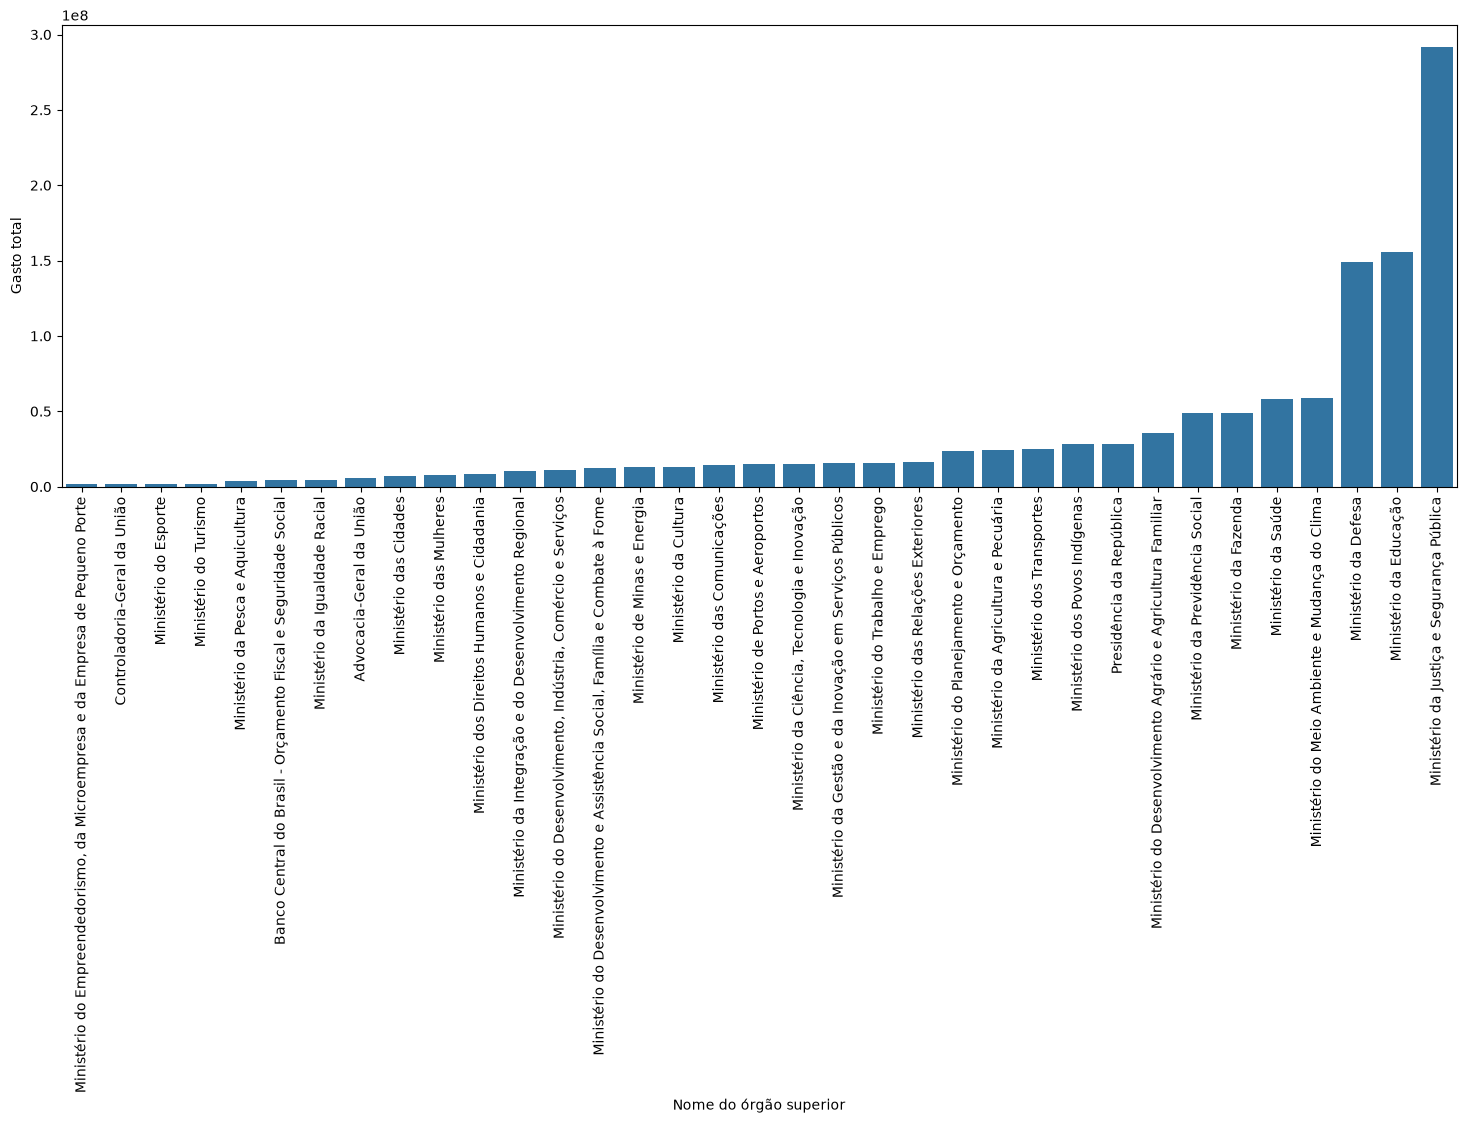

In [60]:
type(df_gasto_total_agrupado_por_orgao_sorted)
plt.figure(figsize=(18, 6))
sns.barplot(data=df_gasto_total_agrupado_por_orgao_sorted, x='Nome do órgão superior',y='Gasto total')
plt.xticks(rotation=90)
plt.show()